# Задание 3. 

Возьмем датасет про доставку еды: в нашем датасете есть базовая информация о доставке (на каком транспортном средстве ехал курьер, было это утром, днем или вечером, в какую погоду и так далее). Проверьте, нет ли в датасете пропущенных ячеек: scikit-learn не умеет работать с отсутствующими данными, их нужно убрать или каким-либо образом заполнить. Используйте One Hot Encoding для категориальных признаков. Обучите линейную регрессию для предсказания времени доставки и посчитайте, на сколько минут в среднем ошибается ваша модель.

In [21]:
import pandas as pd
data = pd.read_csv('/Users/katyamazurina/Desktop/2 sem/ML/Food_Delivery_Times.csv')

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [23]:
data.isnull().sum() # количество пропущенных ячеек

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [24]:
# заполним пропущенные ячейки средними значениями 
data['Courier_Experience_yrs'] = data['Courier_Experience_yrs'].fillna(data['Courier_Experience_yrs'].median())
data['Traffic_Level'] = data['Traffic_Level'].fillna(data['Traffic_Level'].mode()[0])
data['Weather'] = data['Weather'].fillna(data['Weather'].mode()[0])
data['Time_of_Day'] = data['Time_of_Day'].fillna(data['Time_of_Day'].mode()[0])

In [25]:
# применяем OHE к категориальным признакам
data = pd.get_dummies(data, columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'])

In [26]:
# заменяем формат bool на int
data[data.select_dtypes(include=["bool"]).columns] = data.select_dtypes(include=["bool"]).astype(int)

In [27]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["Delivery_Time_min"])  # Берем все признаки, кроме целевой переменной
y = data["Delivery_Time_min"]

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(Xtrain, ytrain) # обучение модели

pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)


In [29]:
mean_squared_error(pred_test, ytest) ** 0.5 


8.855415469134991

In [30]:
mean_squared_error(pred_train, ytrain) ** 0.5


10.83367411121933

<Axes: >

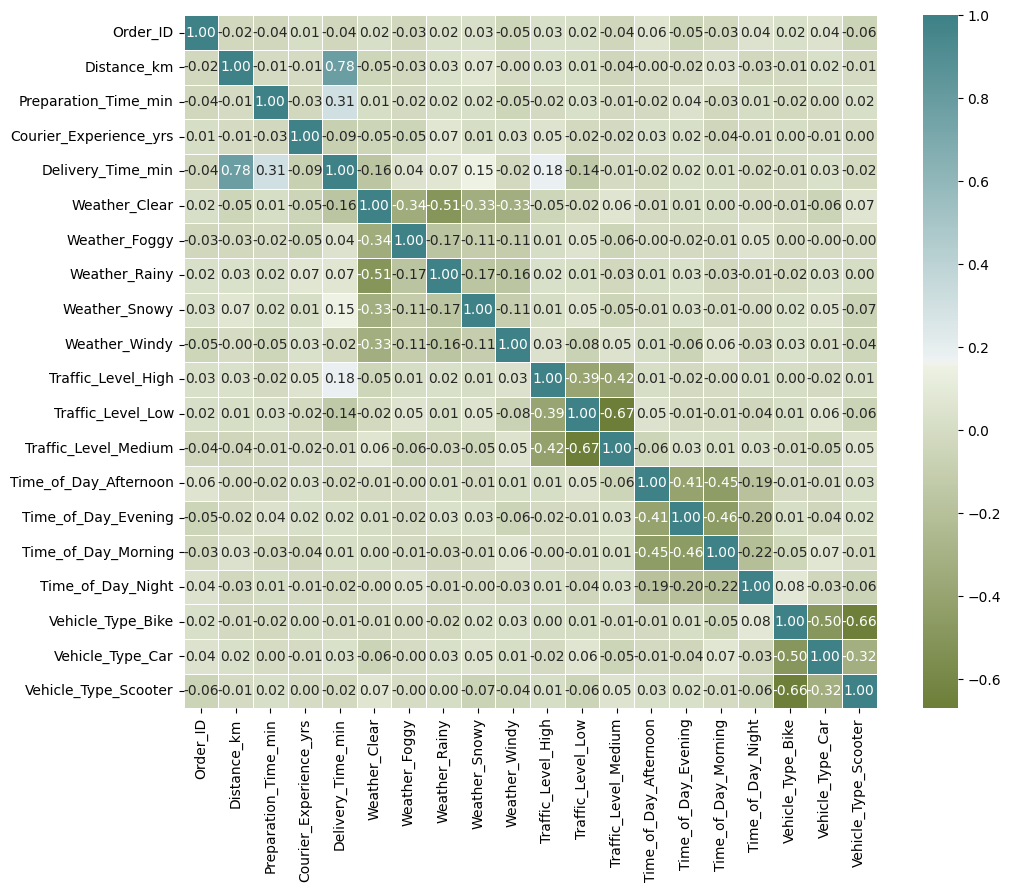

In [31]:
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt
plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)